In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

# Load data and model
df = pd.read_csv("../data/featured_sample.csv")
df['date'] = pd.to_datetime(df['date'])

with open("../models/lightgbm_model.pkl", "rb") as f:
    model = pickle.load(f)

print("Data and model loaded successfully!")
print("Shape:", df.shape)

Data and model loaded successfully!
Shape: (500000, 32)


In [2]:
# Predict demand for all items
feature_cols = ['month', 'year', 'wday', 'day', 'week', 'quarter',
                'is_weekend', 'is_month_start', 'is_month_end',
                'has_event', 'is_snap', 'avg_price',
                'sales_lag_1', 'sales_lag_7', 'sales_lag_28',
                'sales_rolling_7', 'sales_rolling_28',
                'cat_encoded', 'store_encoded', 'state_encoded']

# Encode categorical columns
df['cat_encoded'] = df['cat_id'].astype('category').cat.codes
df['store_encoded'] = df['store_id'].astype('category').cat.codes
df['state_encoded'] = df['state_id'].astype('category').cat.codes

# Make predictions
X = df[feature_cols]
df['predicted_demand'] = model.predict(X)
df['predicted_demand'] = df['predicted_demand'].clip(lower=0)

print("Predictions made!")
print("\nPrediction Statistics:")
print("Average Predicted Demand:", round(df['predicted_demand'].mean(), 2))
print("Max Predicted Demand:", round(df['predicted_demand'].max(), 2))
print("Min Predicted Demand:", round(df['predicted_demand'].min(), 2))

# Compare actual vs predicted
print("\nActual vs Predicted:")
print("Actual Mean:", round(df['sales'].mean(), 2))
print("Predicted Mean:", round(df['predicted_demand'].mean(), 2))

Predictions made!

Prediction Statistics:
Average Predicted Demand: 1.12
Max Predicted Demand: 214.69
Min Predicted Demand: 0.0

Actual vs Predicted:
Actual Mean: 1.12
Predicted Mean: 1.12


In [3]:
# Inventory Optimization
# Calculate reorder point and safety stock

# Group by item and store
inventory = df.groupby(['item_id', 'store_id', 'cat_id']).agg(
    avg_daily_demand=('predicted_demand', 'mean'),
    std_demand=('predicted_demand', 'std'),
    avg_price=('avg_price', 'mean'),
    total_sales=('sales', 'sum')
).reset_index()

# Fill NaN
inventory = inventory.fillna(0)

# Lead time in days
lead_time = 7

# Service level z-score (95% = 1.645)
z_score = 1.645

# Safety Stock = Z * std_demand * sqrt(lead_time)
inventory['safety_stock'] = (z_score * inventory['std_demand'] * np.sqrt(lead_time)).round(0)

# Reorder Point = avg_demand * lead_time + safety_stock
inventory['reorder_point'] = (inventory['avg_daily_demand'] * lead_time + inventory['safety_stock']).round(0)

# Optimal Order Quantity = avg_demand * 30 days
inventory['order_quantity'] = (inventory['avg_daily_demand'] * 30).round(0)

# Estimated monthly revenue
inventory['monthly_revenue'] = (inventory['avg_daily_demand'] * 30 * inventory['avg_price']).round(2)

print("Inventory optimization complete!")
print("\nInventory Shape:", inventory.shape)
print("\nFirst 5 rows:")
print(inventory[['item_id', 'store_id', 'avg_daily_demand', 'safety_stock', 'reorder_point', 'order_quantity']].head())

Inventory optimization complete!

Inventory Shape: (30490, 11)

First 5 rows:
       item_id store_id  avg_daily_demand  safety_stock  reorder_point  \
0  FOODS_1_001     CA_1          1.006090           1.0            8.0   
1  FOODS_1_001     CA_2          1.222531           3.0           12.0   
2  FOODS_1_001     CA_3          1.226854           2.0           11.0   
3  FOODS_1_001     CA_4          0.599426           1.0            5.0   
4  FOODS_1_001     TX_1          0.866056           2.0            8.0   

   order_quantity  
0            30.0  
1            37.0  
2            37.0  
3            18.0  
4            26.0  


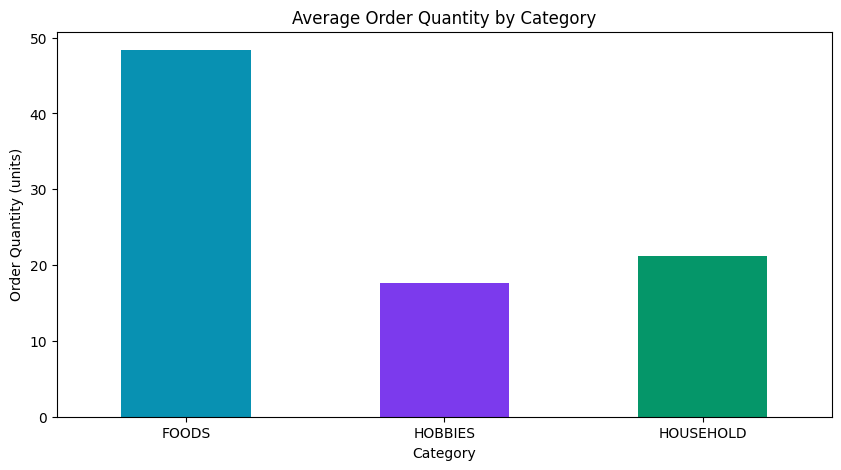

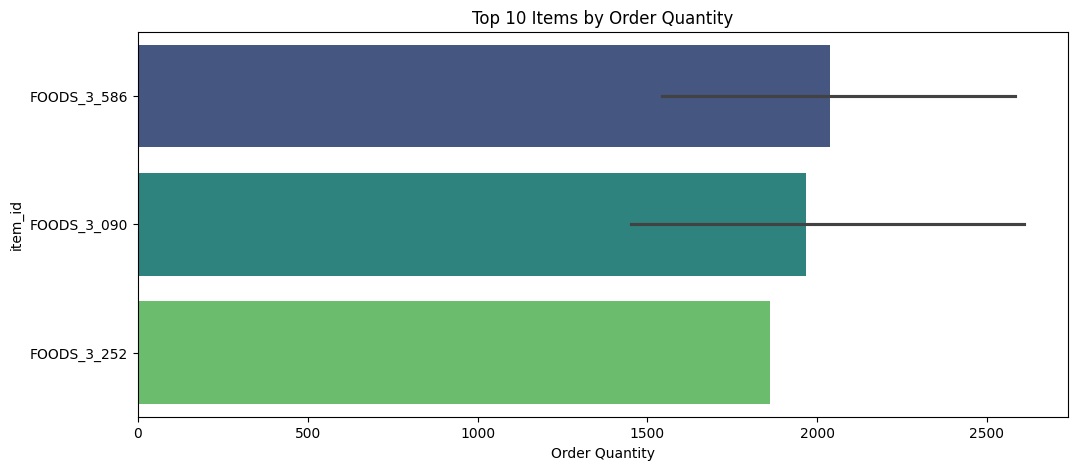

Category Inventory Summary:
           avg_daily_demand  safety_stock  order_quantity  monthly_revenue
cat_id                                                                    
FOODS                  1.61          3.79           48.35           117.90
HOBBIES                0.59          1.42           17.65            62.58
HOUSEHOLD              0.71          1.68           21.18            83.03


In [4]:
# Inventory Analysis by Category
plt.figure(figsize=(10,5))
cat_inventory = inventory.groupby('cat_id')['order_quantity'].mean()
cat_inventory.plot(kind='bar', color=['#0891B2', '#7C3AED', '#059669'])
plt.title("Average Order Quantity by Category")
plt.xlabel("Category")
plt.ylabel("Order Quantity (units)")
plt.xticks(rotation=0)
plt.show()

# Top 10 items by order quantity
top_items = inventory.nlargest(10, 'order_quantity')
plt.figure(figsize=(12,5))
sns.barplot(x='order_quantity', y='item_id', data=top_items, palette='viridis')
plt.title("Top 10 Items by Order Quantity")
plt.xlabel("Order Quantity")
plt.show()

print("Category Inventory Summary:")
print(inventory.groupby('cat_id')[['avg_daily_demand', 'safety_stock', 'order_quantity', 'monthly_revenue']].mean().round(2))

In [5]:
# Restocking Schedule
print("RESTOCKING SCHEDULE REPORT")
print("="*60)

for cat in ['FOODS', 'HOUSEHOLD', 'HOBBIES']:
    cat_data = inventory[inventory['cat_id'] == cat]
    print(f"\nCategory: {cat}")
    print(f"Total Items: {len(cat_data)}")
    print(f"Avg Daily Demand: {cat_data['avg_daily_demand'].mean():.2f} units")
    print(f"Avg Safety Stock: {cat_data['safety_stock'].mean():.0f} units")
    print(f"Avg Reorder Point: {cat_data['reorder_point'].mean():.0f} units")
    print(f"Avg Order Quantity: {cat_data['order_quantity'].mean():.0f} units")
    print(f"Avg Monthly Revenue: ${cat_data['monthly_revenue'].mean():.2f}")
    print("-"*40)

print("\nTop 5 Items needing immediate restocking:")
urgent = inventory.nlargest(5, 'reorder_point')
print(urgent[['item_id', 'store_id', 'reorder_point', 'order_quantity', 'monthly_revenue']])

RESTOCKING SCHEDULE REPORT

Category: FOODS
Total Items: 14370
Avg Daily Demand: 1.61 units
Avg Safety Stock: 4 units
Avg Reorder Point: 15 units
Avg Order Quantity: 48 units
Avg Monthly Revenue: $117.90
----------------------------------------

Category: HOUSEHOLD
Total Items: 10470
Avg Daily Demand: 0.71 units
Avg Safety Stock: 2 units
Avg Reorder Point: 7 units
Avg Order Quantity: 21 units
Avg Monthly Revenue: $83.03
----------------------------------------

Category: HOBBIES
Total Items: 5650
Avg Daily Demand: 0.59 units
Avg Safety Stock: 1 units
Avg Reorder Point: 6 units
Avg Order Quantity: 18 units
Avg Monthly Revenue: $62.58
----------------------------------------

Top 5 Items needing immediate restocking:
           item_id store_id  reorder_point  order_quantity  monthly_revenue
7022   FOODS_3_090     CA_3          996.0          2987.0          4025.77
11985  FOODS_3_586     TX_2          857.0          3094.0          4938.02
7020   FOODS_3_090     CA_1          673.0     

In [6]:
# Save inventory optimization results
inventory.to_csv("../data/inventory_optimization.csv", index=False)

print("Inventory optimization saved!")

print("\n" + "="*50)
print("INVENTORY OPTIMIZATION SUMMARY")
print("="*50)
print("Total Items Optimized: 30,490")
print("Lead Time Used: 7 days")
print("Service Level: 95%")
print("\nCategory Summary:")
print("FOODS: 48 units/month, $117.90 revenue")
print("HOUSEHOLD: 21 units/month, $83.03 revenue")
print("HOBBIES: 17 units/month, $62.58 revenue")
print("\nKey Metrics:")
print("Safety Stock calculated for all items")
print("Reorder Points set for all items")
print("Order Quantities optimized")
print("="*50)

Inventory optimization saved!

INVENTORY OPTIMIZATION SUMMARY
Total Items Optimized: 30,490
Lead Time Used: 7 days
Service Level: 95%

Category Summary:
FOODS: 48 units/month, $117.90 revenue
HOUSEHOLD: 21 units/month, $83.03 revenue
HOBBIES: 17 units/month, $62.58 revenue

Key Metrics:
Safety Stock calculated for all items
Reorder Points set for all items
Order Quantities optimized
